In [ ]:
#%matplotlib widget
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import glob
import os

In [ ]:
def parse_header(file_path):
    header_info = {}
    with open(file_path, 'r') as file:
        for line in file:
            # Stop if we reach the data section
            if line.startswith('-'):
                break

            if ':' in line:
                # Extract key-value pairs and remove the '# ' prefix
                key, value = line.strip().replace('# ', '', 1).split(':', 1)
                
                # Convert key to lowercase and strip specific characters from both key and value
                key = key.lower().strip(';,#" ')
                value = value.strip(';,#" ')
                
                header_info[key] = value.strip()

    return header_info

## READ AND PROCESS CSV FILES

In [ ]:
# Specify the path to your folder
folder_path_1 = os.path.join("C:\\", "Users", "NicolasHeimbuger", "CellEctric Biosciences", "Sepsis Project - Dokumente", "Research", "Lysis process", "Thermal_Oxidation", "Stüken", "675°C5+5h", "LT_1.11", "E_data", "240125_experiment data")
folder_path_2 = os.path.join("C:\\", "Users", "NicolasHeimbuger", "Desktop", "240229_CBST_G2_024ER")

# =============================================================================================================================================
# =============================================================================================================================================

# Create a pattern to match all CSV files
pattern = os.path.join(folder_path_2, '*.csv')

# Use glob to find all files matching the pattern
csv_files = glob.glob(pattern)

dataframes = {}

# Iterate over the list of csv files
filenumber = 0
for file in csv_files:
    # Parse the header
    header_info = parse_header(file)

    # Extracting the filename without the extension to use as a key
    filename = os.path.splitext(os.path.basename(file))[0]
    
    # Reading the csv file into a dataframe
    df = pd.read_csv(file, skiprows=8, names=['voltage', 'current'])

     # Add the header information as new columns to the DataFrame
    for key, value in header_info.items():
        df[key] = value
        
    df["sourcefile"] = filename
    df["filenumber"] = filenumber
    
    # Storing the dataframe in a dictionary with the filename as the key
    dataframes[filename] = df
    filenumber += 1


df_combined = pd.concat(dataframes, ignore_index=True)
df_combined


## GET SPECIFIC GRAPH

In [ ]:
# The name of the file or identifier you're interested in
file_identifier_number = 1

# =============================================================================================================================================
# =============================================================================================================================================

# Filter the DataFrame for rows belonging to the specified file
filtered_df = df_combined[df_combined['filenumber'] == file_identifier_number]
pulsenumber = filtered_df["pulse number"].iloc[0]
print(pulsenumber)

# Plotting
plt.figure(figsize=(10, 6))  # Creates a new figure with a specified size (width, height) in inches
plt.plot(filtered_df['voltage'], linestyle='-', color='b')  # Plots 'column1' data

plt.title('Voltage for pulse number {}'.format(pulsenumber))  # Sets the title of the plot
plt.xlabel('Index')  # Sets the label for the x-axis
plt.ylabel('Voltage')  # Sets the label for the y-axis

plt.grid(True)  # Adds a grid to the plot for better readability
plt.show()  # Displays the plot

## GET ALL GRAPHS

In [ ]:
voltage_threshold = 20



# =============================================================================================================================================
# =============================================================================================================================================

# get number of onique files
number_of_files = len(df_combined['filenumber'].unique())

# remove unuseful files from copied dataframe
df_useful = df_combined.copy()

for file_identifier_number in range(number_of_files):
    if df_useful[df_useful['filenumber'] == file_identifier_number]['voltage'].max() < voltage_threshold:
        index_names = df_useful[df_useful['filenumber'] == file_identifier_number].index
        df_useful.drop(index=index_names, inplace=True)
        print("USLESS PULSE NUMBER: {}".format(file_identifier_number))

# get the number of files including the IDs
useful_file_numbers = df_useful['filenumber'].unique()

# create a colour gradient
cmap = cm.get_cmap('viridis', len(useful_file_numbers))



# set figure size
plt.figure(figsize=(14, 10))  # Creates a new figure with a specified size (width, height) in inches


# ============
# VOLTAGE
# ============

plt.subplot(2, 1, 1)  # Indicates 2 rows, 1 column, this is the 1st subplot

# create plots
for file_identifier_number in useful_file_numbers:
    # Filter the DataFrame for rows belonging to the specified file
    filtered_df = df_useful[df_useful['filenumber'] == file_identifier_number]

    # create unique x-axis
    n = len(filtered_df)
    time_interval = 0.1  # 0.1 microseconds expressed in seconds
    x_axis = np.arange(0, n * time_interval, time_interval)

    # create line in plot
    plt.plot(x_axis, filtered_df['voltage'], color=cmap(file_identifier_number), linestyle='-', alpha=0.4)  # Plots 'column1' data


# Plotting VOLTAGE
plt.title('Voltage pulses')  # Sets the title of the plot
plt.xlabel('Time [μs]')  # Sets the label for the x-axis
plt.ylabel('Voltage [V]')  # Sets the label for the y-axis
plt.grid(True)  # Adds a grid to the plot for better readability


# ============
# CURRENT
# ============

plt.subplot(2, 1, 2)  # Indicates 2 rows, 1 column, this is the 2nd subplot

# create plots
for file_identifier_number in useful_file_numbers:
    # Filter the DataFrame for rows belonging to the specified file
    filtered_df = df_useful[df_useful['filenumber'] == file_identifier_number]

    # create unique x-axis
    n = len(filtered_df)
    time_interval = 0.1  # 0.1 microseconds expressed in seconds
    x_axis = np.arange(0, n * time_interval, time_interval)

    # create line in plot
    plt.plot(x_axis, filtered_df['current'], color=cmap(file_identifier_number), linestyle='-', alpha=0.4)  # Plots 'column1' data

# Plotting VOLTAGE
plt.title('Current pulses')  # Sets the title of the plot
plt.xlabel('Time [μs]')  # Sets the label for the x-axis
plt.ylabel('Current [A]')  # Sets the label for the y-axis
plt.grid(True)  # Adds a grid to the plot for better readability

# Create a colorbar as a legend for the gradient
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=number_of_files))
sm.set_array([])
plt.colorbar(sm, orientation='horizontal', aspect=50, shrink=0.8, ticks=np.arange(0, number_of_files+1),  # +1 to include the last number
             boundaries=np.arange(-0.5, number_of_files+0.5, 1), label='Pulse Number')



plt.tight_layout()  # Automatically adjusts subplot params to give specified padding
plt.show()  # Displays the plot

In [ ]:
df_useful.info()

In [ ]:
df_useful

# PLOT MAX CURRENT PEAKS

In [ ]:
# get the peak index number for each peak to align graphs
triggers = {}
for file_identifier_number in useful_file_numbers:
    max_value_index = df_useful[df_useful['filenumber'] == file_identifier_number]['current'].idxmin()  # idxmin because we are interested in the negative peak only
    triggers[file_identifier_number] = max_value_index

print(triggers)


# cut the dataframe to the used data only
# create a colour gradient
cmap = cm.get_cmap('viridis', len(useful_file_numbers))


# ============
# CURRENT PEAK
# ============

# set figure size
plt.figure(figsize=(14, 6))  # Creates a new figure with a specified size (width, height) in inches

# create plots
for file_identifier_number, trigger_id in triggers.items():
    # Filter the DataFrame for rows belonging to the specified file
    filtered_df = df_useful[df_useful['filenumber'] == file_identifier_number].loc[trigger_id-10:trigger_id+300]
    filtered_df['current'] = filtered_df['current'] * -1

    # create unique x-axis
    n = len(filtered_df)
    time_interval = 0.1  # 0.1 microseconds expressed in seconds
    x_axis = np.arange(0, n * time_interval, time_interval)

    # create line in plot
    plt.plot(x_axis, filtered_df['current'], color=cmap(file_identifier_number), linestyle='-', alpha=0.4)  # Plots 'column1' data


# Create a colorbar as a legend for the gradient
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=number_of_files))
sm.set_array([])
plt.colorbar(sm, orientation='horizontal', aspect=50, shrink=0.8, ticks=np.arange(0, number_of_files+1),  # +1 to include the last number
             boundaries=np.arange(-0.5, number_of_files+0.5, 1), label='Pulse Number')


# Plotting VOLTAGE
plt.title('Current Pulses')  # Sets the title of the plot
plt.xlabel('Time [μs]')  # Sets the label for the x-axis
plt.ylabel('Current [A]')  # Sets the label for the y-axis

plt.grid(True)  # Adds a grid to the plot for better readability
plt.show()  # Displays the plot

## TEMPERATURE, MIN/MAX VOLTAGE, CURRENT PEAK, CHARGE CURRENT (PULSES ONLY)

In [ ]:
temperature_array = []
vmax_array = []
vmin_array = []
imax_array = []
icharge_array = []


for file_identifier_number in useful_file_numbers:
    #temperature
    temperature = df_useful[df_useful['filenumber'] == file_identifier_number]['temperature'].iloc[0] 
    temperature_array.append(float(temperature))
    
    #vmax
    vmax = df_useful[df_useful['filenumber'] == file_identifier_number]['voltage'].max()
    vmax_array.append(vmax)

    #vmin
    vmin = df_useful[df_useful['filenumber'] == file_identifier_number]['voltage'].min()
    vmin_array.append(vmin)

    #current peak
    imax = df_useful[df_useful['filenumber'] == file_identifier_number]['current'].min() * -1
    imax_array.append(imax)

    #chargecurrent (TODO: figure out how it is calculated in octave)
    icharge = df_useful[df_useful['filenumber'] == file_identifier_number]['current'].sum() * -1
    icharge_array.append(icharge)


# Plotting TEMPERATURE
plt.figure(figsize=(14, 6))  # Creates a new figure with a specified size (width, height) in inches
plt.plot(temperature_array)  # Plot the data
plt.title('Temperature')  # Sets the title of the plot
plt.xlabel('Pulse Nr.')  # Sets the label for the x-axis
plt.ylabel('Temperature [°C]')  # Sets the label for the y-axis

plt.grid(True)  # Adds a grid to the plot for better readability
plt.show()  # Displays the plot


# Plotting VMAX
plt.figure(figsize=(14, 6))  # Creates a new figure with a specified size (width, height) in inches
plt.plot(vmax_array)  # Plot the data
plt.title('Vmax')  # Sets the title of the plot
plt.xlabel('Pulse Nr.')  # Sets the label for the x-axis
plt.ylabel('Voltage [V]')  # Sets the label for the y-axis

plt.grid(True)  # Adds a grid to the plot for better readability
plt.show()  # Displays the plot


# Plotting VMIN
plt.figure(figsize=(14, 6))  # Creates a new figure with a specified size (width, height) in inches
plt.plot(vmin_array)  # Plot the data
plt.title('Vmin')  # Sets the title of the plot
plt.xlabel('Pulse Nr.')  # Sets the label for the x-axis
plt.ylabel('Voltage [V]')  # Sets the label for the y-axis

plt.grid(True)  # Adds a grid to the plot for better readability
plt.show()  # Displays the plot


# Plotting CURRENT PEAK
plt.figure(figsize=(14, 6))  # Creates a new figure with a specified size (width, height) in inches
plt.plot(imax_array)  # Plot the data
plt.title('Current Peak')  # Sets the title of the plot
plt.xlabel('Pulse Nr.')  # Sets the label for the x-axis
plt.ylabel('Current [A]')  # Sets the label for the y-axis

plt.grid(True)  # Adds a grid to the plot for better readability
plt.show()  # Displays the plot


# Plotting CHARGE CURRENT
plt.figure(figsize=(14, 6))  # Creates a new figure with a specified size (width, height) in inches
plt.plot(icharge_array)  # Plot the data
plt.title('Electrical Charge (fromer "Charge Current")')  # Sets the title of the plot
plt.xlabel('Pulse Nr.')  # Sets the label for the x-axis
plt.ylabel('Charge [As = C]')  # Sets the label for the y-axis

plt.grid(True)  # Adds a grid to the plot for better readability
plt.show()  # Displays the plot



## TEMPERATURE, MIN/MAX VOLTAGE, CURRENT PEAK, CHARGE CURRENT

In [ ]:
temperature_array = []
vmax_array = []
vmin_array = []
imax_array = []
icharge_array = []

useful_file_numbers = df_combined['filenumber'].unique()

for file_identifier_number in useful_file_numbers:
    #temperature
    temperature = df_combined[df_combined['filenumber'] == file_identifier_number]['temperature'].iloc[0] 
    temperature_array.append(float(temperature))
    
    #vmax
    vmax = df_combined[df_combined['filenumber'] == file_identifier_number]['voltage'].max()
    vmax_array.append(vmax)

    #vmin
    vmin = df_combined[df_combined['filenumber'] == file_identifier_number]['voltage'].min()
    vmin_array.append(vmin)

    #current peak
    imax = df_combined[df_combined['filenumber'] == file_identifier_number]['current'].min() * -1
    imax_array.append(imax)

    #chargecurrent (TODO: figure out how it is calculated in octave)
    icharge = df_combined[df_combined['filenumber'] == file_identifier_number]['current'].sum() * -1
    icharge_array.append(icharge)


# Plotting TEMPERATURE
plt.figure(figsize=(14, 6))  # Creates a new figure with a specified size (width, height) in inches
plt.plot(temperature_array)  # Plot the data
plt.title('Temperature')  # Sets the title of the plot
plt.xlabel('Pulse Nr.')  # Sets the label for the x-axis
plt.ylabel('Temperature [°C]')  # Sets the label for the y-axis

plt.grid(True)  # Adds a grid to the plot for better readability
plt.show()  # Displays the plot


# Plotting VMAX
plt.figure(figsize=(14, 6))  # Creates a new figure with a specified size (width, height) in inches
plt.plot(vmax_array)  # Plot the data
plt.title('Vmax')  # Sets the title of the plot
plt.xlabel('Pulse Nr.')  # Sets the label for the x-axis
plt.ylabel('Voltage [V]')  # Sets the label for the y-axis

plt.grid(True)  # Adds a grid to the plot for better readability
plt.show()  # Displays the plot


# Plotting VMIN
plt.figure(figsize=(14, 6))  # Creates a new figure with a specified size (width, height) in inches
plt.plot(vmin_array)  # Plot the data
plt.title('Vmin')  # Sets the title of the plot
plt.xlabel('Pulse Nr.')  # Sets the label for the x-axis
plt.ylabel('Voltage [V]')  # Sets the label for the y-axis

plt.grid(True)  # Adds a grid to the plot for better readability
plt.show()  # Displays the plot


# Plotting CURRENT PEAK
plt.figure(figsize=(14, 6))  # Creates a new figure with a specified size (width, height) in inches
plt.plot(imax_array)  # Plot the data
plt.title('Current Peak')  # Sets the title of the plot
plt.xlabel('Pulse Nr.')  # Sets the label for the x-axis
plt.ylabel('Current [A]')  # Sets the label for the y-axis

plt.grid(True)  # Adds a grid to the plot for better readability
plt.show()  # Displays the plot


# Plotting CHARGE CURRENT
plt.figure(figsize=(14, 6))  # Creates a new figure with a specified size (width, height) in inches
plt.plot(icharge_array)  # Plot the data
plt.title('Electrical Charge (fromer "Charge Current")')  # Sets the title of the plot
plt.xlabel('Pulse Nr.')  # Sets the label for the x-axis
plt.ylabel('Charge [As = C]')  # Sets the label for the y-axis

plt.grid(True)  # Adds a grid to the plot for better readability
plt.show()  # Displays the plot



## VOLTAGE DROP

# NEW IMPLEMENTATION

In [1]:
#%matplotlib widget
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import stats
import glob
import os

def parse_header(file_path):
    header_info = {}
    with open(file_path, 'r') as file:
        for line in file:
            # Stop if we reach the data section
            if line.startswith('-'):
                break

            if ':' in line:
                # Extract key-value pairs and remove the '# ' prefix
                key, value = line.strip().replace('# ', '', 1).split(':', 1)
                
                # Convert key to lowercase and strip specific characters from both key and value
                key = key.lower().strip(';,#" ')
                value = value.strip(';,#" ')
                
                header_info[key] = value.strip()

    return header_info

In [2]:
# Specify the path to your folder
folder_path_1 = os.path.join("C:\\", "Users", "NicolasHeimbuger", "CellEctric Biosciences", "Sepsis Project - Dokumente", "Research", "Lysis process", "Thermal_Oxidation", "Stüken", "675°C5+5h", "LT_1.11", "E_data", "240125_experiment data")
folder_path_2 = os.path.join("C:\\", "Users", "NicolasHeimbuger", "Desktop", "240229_CBST_G2_024ER")

# =============================================================================================================================================
# =============================================================================================================================================

# Create a pattern to match all CSV files
pattern = os.path.join(folder_path_2, '*.csv')

# Use glob to find all files matching the pattern
csv_files = glob.glob(pattern)

# Initialize an empty DataFrame
df_metadata = pd.DataFrame()

# place holder for all temporary dataframes for each CSV file to concat at the end
dataframes = {} 

# Iterate over the list of csv files and remember file number
for filenumber, file in enumerate(csv_files):
    # META-DATA DATAFRAME
    header_info = parse_header(file)        # Parse the header
    header_info["filenumber"] = filenumber  # Add the info of the file number for the meta data
    filename = os.path.splitext(os.path.basename(file))[0]  # Extracting the filename without the extension to use as a key
    header_info["filename"] = filename  # Add the info of the file number for the meta data
    
    df_metadata = pd.concat([df_metadata, pd.DataFrame([header_info])], ignore_index=True)
    
    # Reading the csv file into a temporary dataframe
    df_temp = pd.read_csv(file, skiprows=8, names=['voltage', 'current'])

    # Adding the filenumber as an identifier and the timestamp to each datapoint
    df_temp["filenumber"] = filenumber
    df_temp["time"] = np.arange(start=0, stop=len(df_temp) * 0.1, step=0.1).round(1)

    # Storing the dataframe in a dictionary with the filename as the key
    dataframes[filename] = df_temp

# combine the dataframes
df_combined = pd.concat(dataframes, ignore_index=True)

# set the index
df_metadata.set_index('filenumber', inplace=True)                # single index
df_experiment = df_combined.set_index(['filenumber', 'time'])    # multi index

In [ ]:
df_metadata.head()

In [ ]:
df_experiment.head()

In [ ]:
df_experiment.loc[4]["voltage"].max()


In [ ]:
df_experiment.index.get_level_values(0).unique()

In [ ]:
df_experiment.drop(0)

USLESS PULSE NUMBER: 0
USLESS PULSE NUMBER: 1
USLESS PULSE NUMBER: 30
USLESS PULSE NUMBER: 31
USLESS PULSE NUMBER: 32
USLESS PULSE NUMBER: 33
USLESS PULSE NUMBER: 34
USLESS PULSE NUMBER: 35
USLESS PULSE NUMBER: 36
USLESS PULSE NUMBER: 37
USLESS PULSE NUMBER: 38
USLESS PULSE NUMBER: 39
USLESS PULSE NUMBER: 40
USLESS PULSE NUMBER: 41
USLESS PULSE NUMBER: 42
USLESS PULSE NUMBER: 43
USLESS PULSE NUMBER: 44
USLESS PULSE NUMBER: 45
USLESS PULSE NUMBER: 46
USEFUL FILE NUMBERS:
Int64Index([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
            19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29],
           dtype='int64', name='filenumber')
TRIGGER INDEX:  {2: 78.3, 3: 78.9, 4: 78.9, 5: 79.4, 6: 78.7, 7: 78.3, 8: 79.0, 9: 78.7, 10: 77.9, 11: 78.8, 12: 79.0, 13: 79.0, 14: 70.3, 15: 78.4, 16: 78.0, 17: 79.2, 18: 78.4, 19: 71.5, 20: 79.0, 21: 78.8, 22: 78.0, 23: 78.6, 24: 79.0, 25: 77.9, 26: 77.9, 27: 79.1, 28: 78.1, 29: 77.8}
TRIGGER:	mean	std_dev	min	max	span
		78.03	2.07	70.30	

C:\Users\NicolasHeimbuger\AppData\Local\Temp\ipykernel_9928\3729563499.py:81: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis', len(useful_unique_files)) # create a colour gradient
C:\Users\NicolasHeimbuger\AppData\Local\Temp\ipykernel_9928\3729563499.py:139: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  plt.colorbar(sm, orientation='horizontal', aspect=50, shrink=0.8, ticks=np.arange(0, len(useful_unique_files)+1),  # +1 to include the last number


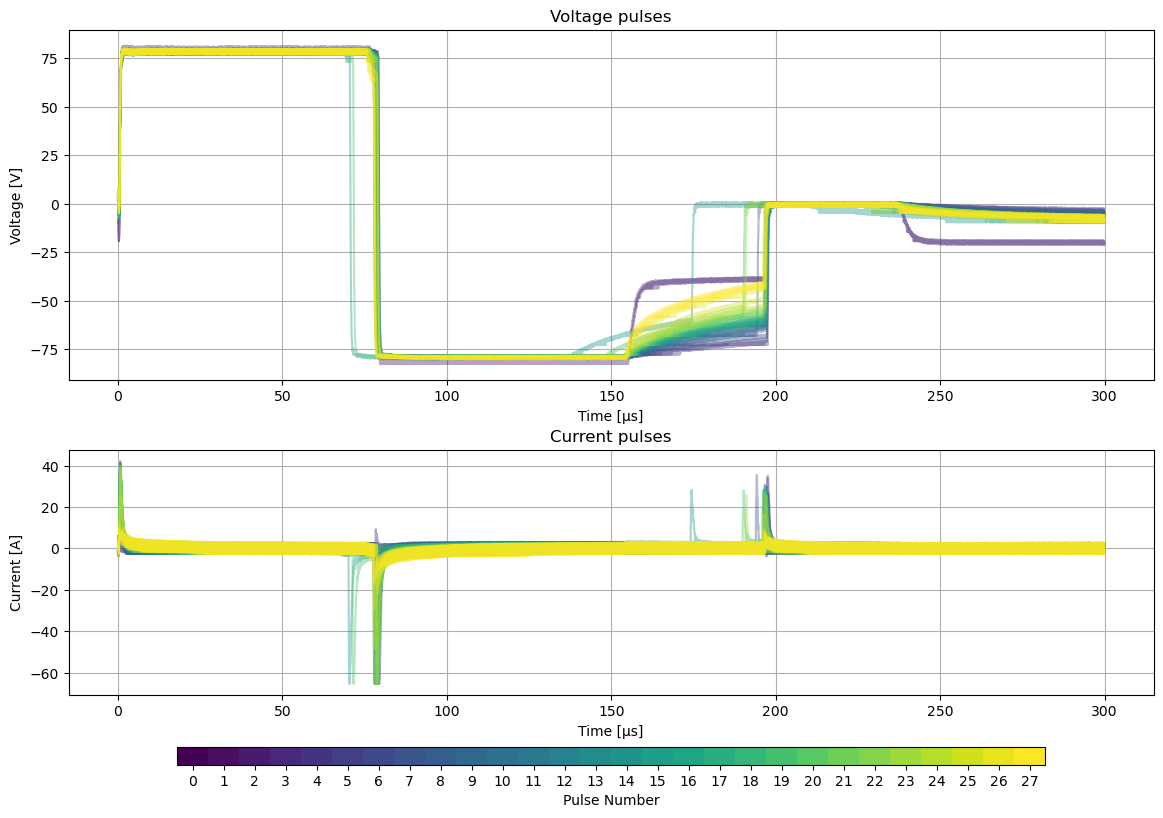

C:\Users\NicolasHeimbuger\AppData\Local\Temp\ipykernel_9928\3729563499.py:180: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  plt.colorbar(sm, orientation='horizontal', aspect=50, shrink=0.8, ticks=np.arange(0, len(useful_unique_files)+1),  # +1 to include the last number


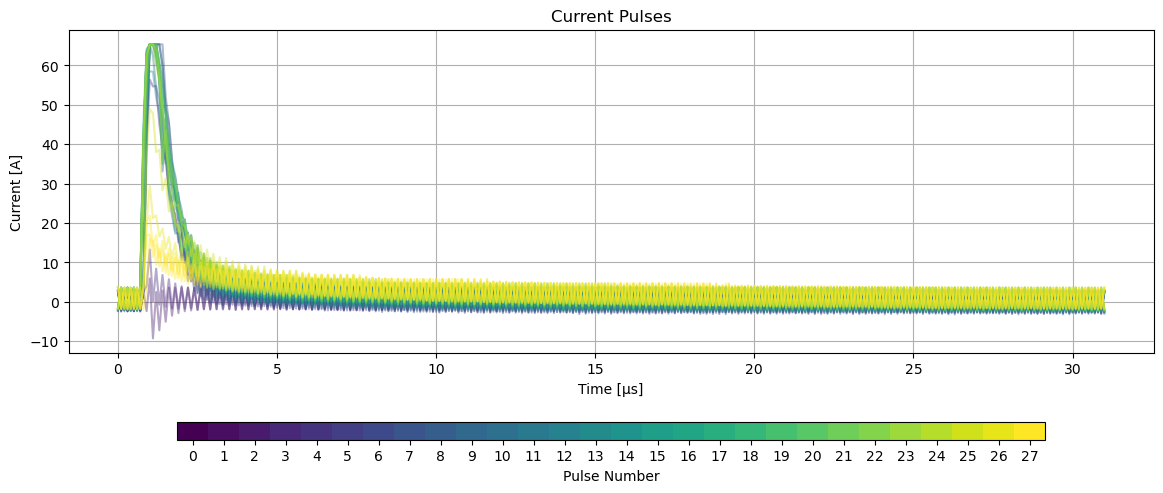

C:\Users\NicolasHeimbuger\AppData\Local\Temp\ipykernel_9928\3729563499.py:217: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  plt.colorbar(sm, orientation='horizontal', aspect=50, shrink=0.8, ticks=np.arange(0, len(useful_unique_files)+1),  # +1 to include the last number


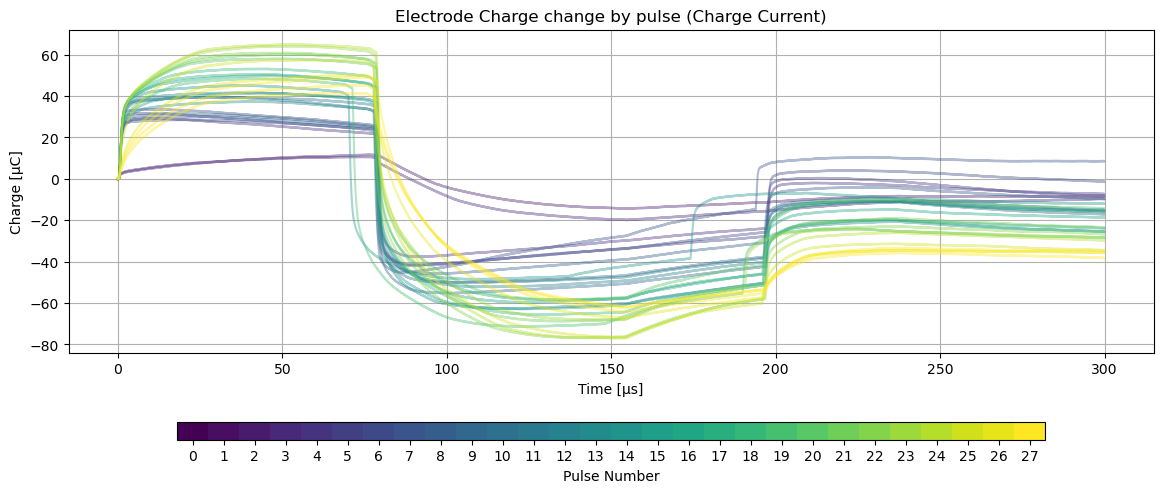

C:\Users\NicolasHeimbuger\AppData\Local\Temp\ipykernel_9928\3729563499.py:244: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_times = cm.get_cmap('viridis', len(charge_durations)) # create a colour gradient


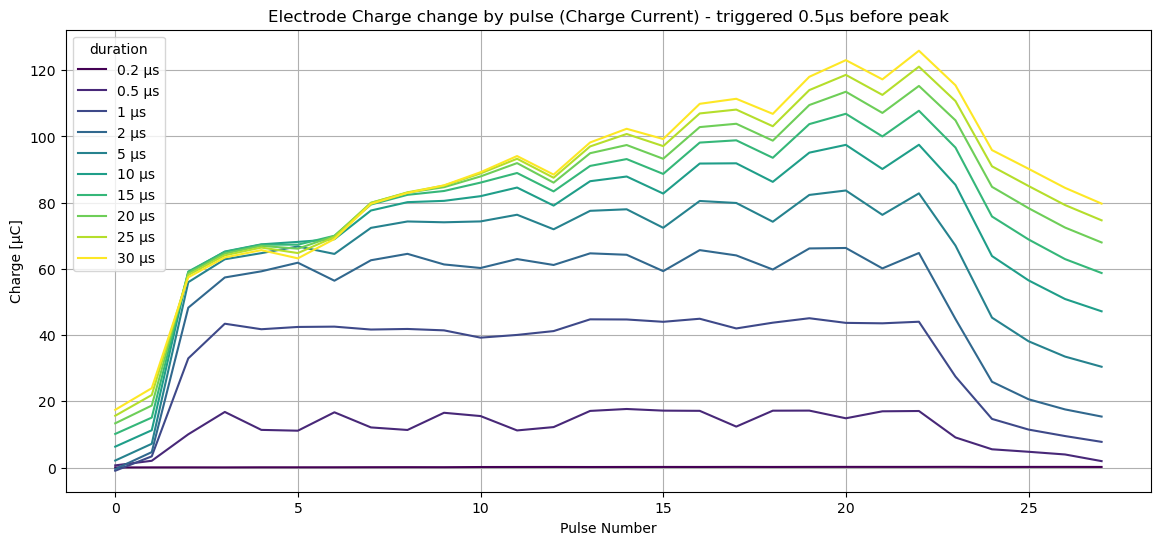

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


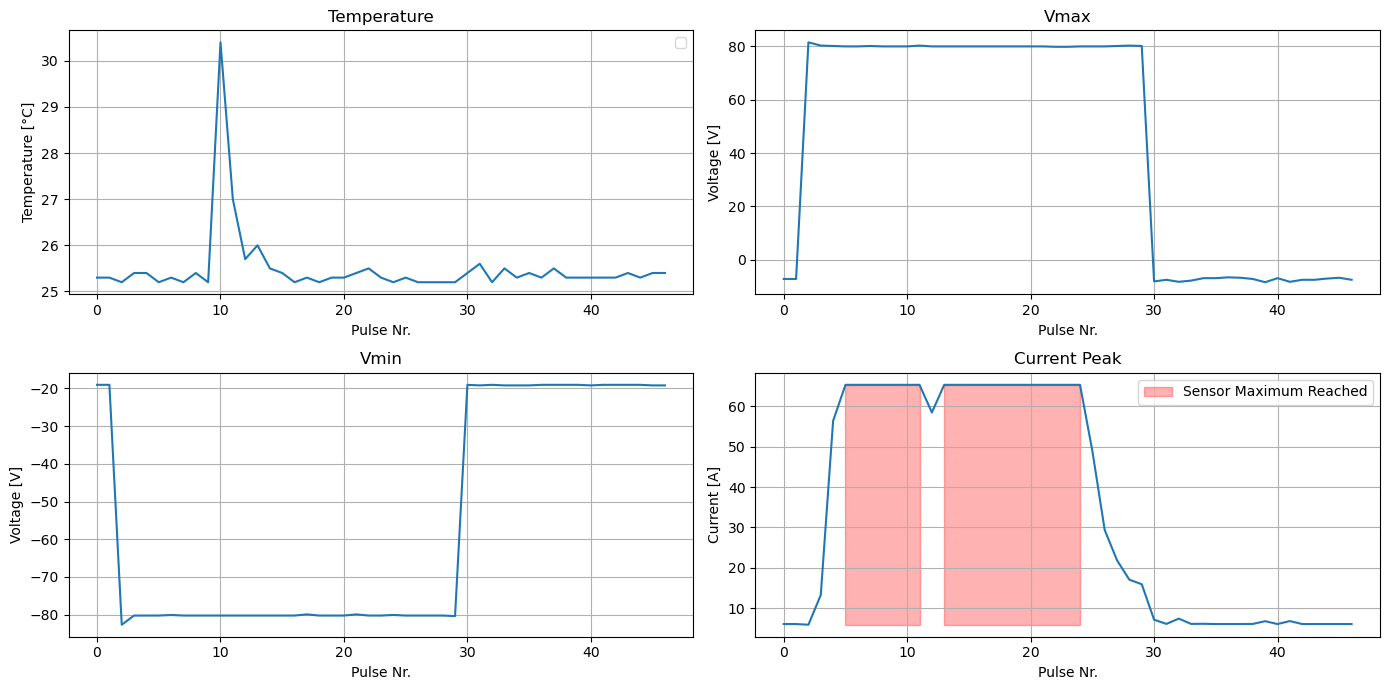

In [159]:
voltage_threshold = 20
th_max_current = 65
th_max_temperature = 37
th_warning_temperature = 34
transparency = 0.4


# =============================================================================================================================================
# PREPARATION
# =============================================================================================================================================

# get array of all unique files (populated with filenumbers)
unique_files = df_experiment.index.get_level_values(0).unique()

# copy dataframe to edit it inplace afterwards
df_experiment_useful = df_experiment.copy()

# delete (drop) unnecessary files (filenumber)
for filenumber_iterator in unique_files:
    if df_experiment.loc[filenumber_iterator]['voltage'].max() < voltage_threshold:   # check if maximum value for the current file is smaller than the threshold
        df_experiment_useful.drop(filenumber_iterator, inplace=True)
        print("USLESS PULSE NUMBER: {}".format(filenumber_iterator))

useful_unique_files = df_experiment_useful.index.get_level_values(0).unique()
print("USEFUL FILE NUMBERS:\n{}".format(useful_unique_files))

# -------------------------------------------------------------------------------------------------------------------------

# get the peak index number for each peak to align graphs
triggers = {}
for filenumber_iterator in useful_unique_files:
    max_value_index = df_experiment_useful.loc[filenumber_iterator]['current'].idxmin()  # idxmin because we are interested in the negative peak only
    triggers[filenumber_iterator] = max_value_index

print("TRIGGER INDEX: ", triggers)

# get variance and normal distribution of trigger index
trigger_time_values = list(triggers.values())
trigger_min = min(trigger_time_values)
trigger_max = max(trigger_time_values)
trigger_span = trigger_max - trigger_min
trigger_mean = stats.tmean(trigger_time_values)
trigger_std_dev = stats.tstd(trigger_time_values, ddof=1)
print(f"TRIGGER:\tmean\tstd_dev\tmin\tmax\tspan\n\t\t{trigger_mean:.2f}\t{trigger_std_dev:.2f}\t{trigger_min:.2f}\t{trigger_max:.2f}\t{trigger_span:.2f}")

# -------------------------------------------------------------------------------------------------------------------------

# calculate charge current
df_experiment_useful['charge'] = df_experiment_useful.groupby(level=0)['current'].cumsum()

# -------------------------------------------------------------------------------------------------------------------------

# get other stats (temperature, vmax, vmin, imax)
vmax_array = []
vmin_array = []
imax_array = []


for filenumber_iterator in unique_files:
    #vmax
    vmax = df_experiment.loc[filenumber_iterator]['voltage'].max()
    vmax_array.append(vmax)

    #vmin
    vmin = df_experiment.loc[filenumber_iterator]['voltage'].min()
    vmin_array.append(vmin)

    #current peak
    imax = df_experiment.loc[filenumber_iterator]['current'].min() * -1
    imax_array.append(imax)

vmax_array = np.array(vmax_array)
vmin_array = np.array(vmin_array)
imax_array = np.array(imax_array)

# =============================================================================================================================================
# PRINTING USEFUL GRAPHS
# =============================================================================================================================================


cmap = cm.get_cmap('viridis', len(useful_unique_files)) # create a colour gradient

# ========================
# PLOT 1
# ========================

plt.figure(figsize=(14, 10))  # set figure size

# ============
# VOLTAGE PLOT
# ============

plt.subplot(2, 1, 1)  # Indicates 2 rows, 1 column, this is the 1st subplot

# create plots
for filenumber_iterator in useful_unique_files:
    # create a single line in plot
    plt.plot(
        df_experiment_useful.loc[filenumber_iterator].index.get_level_values('time'),
        df_experiment_useful.loc[filenumber_iterator]['voltage'],
        color=cmap(filenumber_iterator),
        linestyle='-',
        alpha=transparency)

# Plotting VOLTAGE diagram
plt.title('Voltage pulses')  # Sets the title of the plot
plt.xlabel('Time [μs]')  # Sets the label for the x-axis
plt.ylabel('Voltage [V]')  # Sets the label for the y-axis
plt.grid(True)  # Adds a grid to the plot for better readability


# ============
# CURRENT PLOT
# ============

plt.subplot(2, 1, 2)  # Indicates 2 rows, 1 column, this is the 2nd subplot

# create plots
for filenumber_iterator in useful_unique_files:
    # create a single line in plot
    plt.plot(
        df_experiment_useful.loc[filenumber_iterator].index.get_level_values('time'),
        df_experiment_useful.loc[filenumber_iterator]['current'],
        color=cmap(filenumber_iterator),
        linestyle='-',
        alpha=transparency)


# Plotting VOLTAGE
plt.title('Current pulses')  # Sets the title of the plot
plt.xlabel('Time [μs]')  # Sets the label for the x-axis
plt.ylabel('Current [A]')  # Sets the label for the y-axis
plt.grid(True)  # Adds a grid to the plot for better readability


# Create a colorbar as a legend for the gradient
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=len(useful_unique_files)))
sm.set_array([])
plt.colorbar(sm, orientation='horizontal', aspect=50, shrink=0.8, ticks=np.arange(0, len(useful_unique_files)+1),  # +1 to include the last number
             boundaries=np.arange(-0.5, len(useful_unique_files)+0.5, 1), label='Pulse Number')


#plt.tight_layout()  # Automatically adjusts subplot params to give specified padding
plt.show()  # Displays the plot







# ========================
# PLOT 2
# ========================

# ============
# CURRENT PEAK
# ============

# set figure size
plt.figure(figsize=(14, 6))  # Creates a new figure with a specified size (width, height) in inches

# create plots
for filenumber_iterator, trigger_time in triggers.items():
    # Filter the DataFrame for rows belonging to the specified file
    filtered_df = df_experiment_useful.loc[filenumber_iterator].loc[trigger_time-1:trigger_time+30]
    filtered_df['current'] = filtered_df['current'] * -1

    # create line in plot
    plt.plot(
        np.arange(0, len(filtered_df)*0.1, 0.1).round(1),
        filtered_df['current'],
        color=cmap(filenumber_iterator),
        linestyle='-',
        alpha=transparency)

# Create a colorbar as a legend for the gradient
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=len(useful_unique_files)))
sm.set_array([])
plt.colorbar(sm, orientation='horizontal', aspect=50, shrink=0.8, ticks=np.arange(0, len(useful_unique_files)+1),  # +1 to include the last number
             boundaries=np.arange(-0.5, len(useful_unique_files)+0.5, 1), label='Pulse Number')


# Plotting VOLTAGE
plt.title('Current Pulses')  # Sets the title of the plot
plt.xlabel('Time [μs]')  # Sets the label for the x-axis
plt.ylabel('Current [A]')  # Sets the label for the y-axis

plt.grid(True)  # Adds a grid to the plot for better readability
plt.show()  # Displays the plot


# ========================
# PLOT 3
# ========================

# ============
# "CHARGE CURRENT"
# ============

# set figure size
plt.figure(figsize=(14, 6))  # Creates a new figure with a specified size (width, height) in inches

# create plots
for filenumber_iterator in useful_unique_files:
    # create a single line in plot
    plt.plot(
        df_experiment_useful.loc[filenumber_iterator].index.get_level_values('time'),
        df_experiment_useful.loc[filenumber_iterator]['charge']*0.1,
        color=cmap(filenumber_iterator),
        linestyle='-',
        alpha=transparency)

# Create a colorbar as a legend for the gradient
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=len(useful_unique_files)))
sm.set_array([])
plt.colorbar(sm, orientation='horizontal', aspect=50, shrink=0.8, ticks=np.arange(0, len(useful_unique_files)+1),  # +1 to include the last number
             boundaries=np.arange(-0.5, len(useful_unique_files)+0.5, 1), label='Pulse Number')


# Plotting VOLTAGE
plt.title('Electrode Charge change by pulse (Charge Current)')  # Sets the title of the plot
plt.xlabel('Time [μs]')  # Sets the label for the x-axis
plt.ylabel('Charge [μC]')  # Sets the label for the y-axis

plt.grid(True)  # Adds a grid to the plot for better readability
plt.show()  # Displays the plot


# ========================
# PLOT 4
# ========================

# ============
# "CHARGE CURRENT" OVER TIME
# ============

# set figure size
plt.figure(figsize=(14, 6))  # Creates a new figure with a specified size (width, height) in inches

charge_durations = [0.2, 0.5, 1, 2, 5, 10, 15, 20, 25, 30]
charge_starttime = -0.5 # minimum -1

cmap_times = cm.get_cmap('viridis', len(charge_durations)) # create a colour gradient

# create plots
for line_number, duration in enumerate(charge_durations):
    charge_current = []
    charge_endtime = charge_starttime + duration
    for filenumber_iterator, trigger_time in triggers.items():
        # Filter the DataFrame for rows belonging to the specified file
        filtered_df = df_experiment_useful.loc[filenumber_iterator].loc[trigger_time-1:trigger_time+30] # Filter for trigger point
        filtered_df = filtered_df.reset_index()                                                         # reset the index and get "time" column back into dataframe
        filtered_df["delta_time"] = np.arange(-1, len(filtered_df)*0.1-1, 0.1).round(1)                 # create new column which represents the time from the trigger point
        filtered_df.set_index("delta_time")                                                             # set it as the new index

        charge = filtered_df.loc[filtered_df['delta_time'] == charge_endtime, 'charge'].iloc[0] - filtered_df.loc[filtered_df['delta_time'] == charge_starttime, 'charge'].iloc[0]
        charge_current.append(charge*-1 / 10) # Append to array --> flip and scale (to μC) 
    
    # create a single line in plot
    plt.plot(
    charge_current,
    color=cmap_times(line_number),
    linestyle='-',
    label="{} μs".format(duration),
    alpha=1)

# Create a colorbar as a legend for the gradient



# Plotting VOLTAGE
plt.title('Electrode Charge change by pulse (Charge Current) - triggered {}μs before peak'.format(abs(charge_starttime)))  # Sets the title of the plot
plt.xlabel('Pulse Number')  # Sets the label for the x-axis
plt.ylabel('Charge [μC]')  # Sets the label for the y-axis
plt.legend(title='duration')

plt.grid(True)  # Adds a grid to the plot for better readability
plt.show()  # Displays the plot


# ========================
# PLOT 4
# ========================


fig, axs = plt.subplots(2, 2, figsize=(14, 7))  # Creates a 2x2 grid of subplots

# Temperature
df_metadata['temperature'] = pd.to_numeric(df_metadata['temperature'], errors='coerce')
y_temp = df_metadata["temperature"].values
x_temp = np.arange(len(y_temp))
axs[0, 0].plot(x_temp, y_temp)
axs[0, 0].set_title('Temperature')
axs[0, 0].set_xlabel('Pulse Nr.')
axs[0, 0].set_ylabel('Temperature [°C]')
axs[0, 0].grid(True)
# Highlight area where Current Peak exceeds th_warning_temperature
if y_temp.max() > th_warning_temperature:
    axs[0, 0].fill_between(x_temp, y_temp, y_temp.min(), where=(y_temp > th_warning_temperature), color='yellow', alpha=0.3, label='{}°C Reached'.format(th_warning_temperature))
# Highlight area where Current Peak exceeds th_max_temperature
if y_temp.max() > th_max_temperature:
    axs[0, 0].fill_between(x_temp, y_temp, th_warning_temperature, where=(y_temp > th_max_temperature), color='red', alpha=0.3, label='Maximum Temperature Reached')
axs[0, 0].legend()

# Vmax
axs[0, 1].plot(vmax_array)
axs[0, 1].set_title('Vmax')
axs[0, 1].set_xlabel('Pulse Nr.')
axs[0, 1].set_ylabel('Voltage [V]')
axs[0, 1].grid(True)

# Vmin
axs[1, 0].plot(vmin_array)
axs[1, 0].set_title('Vmin')
axs[1, 0].set_xlabel('Pulse Nr.')
axs[1, 0].set_ylabel('Voltage [V]')
axs[1, 0].grid(True)

# Current Peak
x = np.arange(len(imax_array))
axs[1, 1].plot(x, imax_array)
axs[1, 1].set_title('Current Peak')
axs[1, 1].set_xlabel('Pulse Nr.')
axs[1, 1].set_ylabel('Current [A]')
axs[1, 1].grid(True)
# Highlight area where Current Peak exceeds th_max_current
if imax_array.max() > th_max_current:
    axs[1, 1].fill_between(x, imax_array, imax_array.min(), where=(imax_array > th_max_current), color='red', alpha=0.3, label='Sensor Maximum Reached')
axs[1, 1].legend()

plt.tight_layout()  # Adjusts subplot params so that subplots fit in the figure area
plt.show()








In [43]:
filtered_df = df_experiment_useful.loc[2].loc[78.3-1:78.3+30]
filtered_df = filtered_df.reset_index()
filtered_df["delta_time"] = np.arange(-1, len(filtered_df)*0.1-1, 0.1)
filtered_df.set_index("delta_time")

,time,voltage,current,charge
delta_time,,,,
-1.0,77.3,73.2421,-2.65198,103.662357
-0.9,77.4,75.5262,2.24915,105.911507
-0.8,77.5,72.0240,-2.68555,103.225957
-0.7,77.6,72.9376,2.28271,105.508667
-0.6,77.7,68.3695,-2.65198,102.856687
...,...,...,...,...
29.6,107.9,-82.6829,-2.85339,-71.871673
29.7,108.0,-81.0079,2.24915,-69.622523
29.8,108.1,-82.6829,-2.92053,-72.543053


In [ ]:
df_experiment_useful.loc[2]['current'].idxmin()

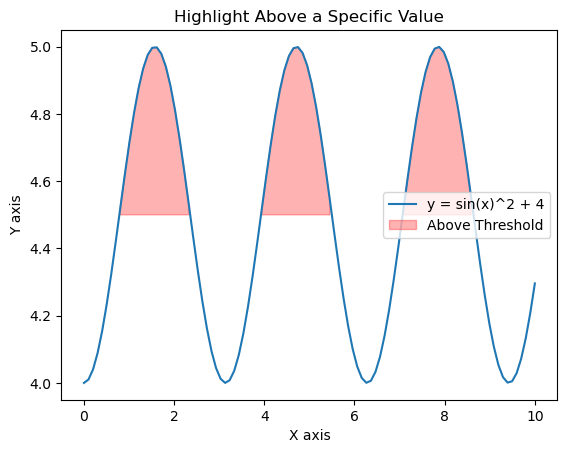

In [133]:
# Sample data
x = np.linspace(0, 10, 100)
y = np.sin(x)**2 + 4  # Example function

# Plot the line
plt.plot(x, y, label='y = sin(x)^2 + 4')

# Highlight area where y > 5
threshold = 4.5
plt.fill_between(x, y, threshold, where=(y > threshold), color='red', alpha=0.3, label='Above Threshold')

# Add labels, legend, and show plot
plt.xlabel('X axis')
plt.ylabel('Y axis')
plt.title('Highlight Above a Specific Value')
plt.legend()
plt.show()

## TKINTER FILE CHOOSER
(DOES NOT WORK NOW)

In [ ]:
import tkinter as tk
from tkinter import filedialog

def select_folder():
    # Create a root window, but don't show it
    root = tk.Tk()
    root.withdraw()  # This hides the main window

    # Open a dialog to select a folder, this will be a blocking call
    folder_selected = filedialog.askdirectory()

    # The user's selection is stored in folder_selected
    print("Selected folder:", folder_selected)

    # Clean up the root window
    root.destroy()

    return folder_selected

# Usage
folder_path = select_folder()
print("Folder path selected:", folder_path)


In [ ]:
from ipyfilechooser import FileChooser
from IPython.display import display

# Create a file chooser for directories
fc = FileChooser()
fc.show_only_dirs = True

folder_selected = False

def on_folder_selected(change):
    # This function will be called when a folder is selected
    selected_folder = fc.selected_path
    print("Selected folder:", selected_folder)
    # Perform further actions here, e.g., read files from the selected directory
    
# Register the event handler (callback function) for when a folder is selected
fc.register_callback(on_folder_selected)

# Display the file chooser widget
display(fc)